# Initial Run
using CICHoneynet_July1.csv

In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.neural_network import MLPRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

HONEYPOT_IP = "192.168.10.111"

c:\Users\Lazaro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
raw = pd.read_csv("CICHoneynet_July1.csv", encoding="latin1")
print(f"Total packets in capture: {len(raw)}")

def is_private(ip):
    try:
        parts = ip.split(".")
        if len(parts) != 4:
            return False
        a, b = int(parts[0]), int(parts[1])
        return a == 10 or (a == 172 and 16 <= b <= 31) or (a == 192 and b == 168)
    except ValueError:
        return False

Total packets in capture: 322747


In [3]:
raw["src_private"] = raw["Source"].apply(is_private)
inbound = raw[
    (raw["Destination"] == HONEYPOT_IP) & (~raw["src_private"])
].copy()
inbound = inbound.drop(columns=["src_private"])
inbound = inbound.rename(columns={
    "Source": "source_ip",
    "Time": "time_sec",
    "Protocol": "protocol",
    "Length": "length",
    "Info": "info",
})

print(f"Inbound attacker packets: {len(inbound)}")
print(f"Unique attacker IPs: {inbound['source_ip'].nunique()}")
print()

Inbound attacker packets: 174663
Unique attacker IPs: 1179



In [4]:
before = len(inbound)
inbound = inbound.drop_duplicates()
print(f"Duplicates removed: {before - len(inbound)}")
inbound["info"] = inbound["info"].fillna("")
inbound = inbound.dropna(subset=["source_ip", "time_sec"])
inbound = inbound.sort_values("time_sec").reset_index(drop=True)
print(f"Packets after cleaning: {len(inbound)}")
print()

Duplicates removed: 0
Packets after cleaning: 174663



In [5]:
port_pattern = re.compile(r"(\d+)\s*>\s*(\d+)")
flag_pattern = re.compile(r"\[([^\]]+)\]")

def parse_info(info):
    src_port, dst_port = np.nan, np.nan
    flags = []
    m = port_pattern.search(info)
    if m:
        src_port, dst_port = int(m.group(1)), int(m.group(2))
    f = flag_pattern.search(info)
    if f:
        flags = [x.strip() for x in f.group(1).split(",")]
    return pd.Series({
        "src_port": src_port,
        "dst_port": dst_port,
        "has_syn": int("SYN" in flags),
        "has_ack": int("ACK" in flags),
        "has_fin": int("FIN" in flags),
        "has_rst": int("RST" in flags),
        "has_psh": int("PSH" in flags),
    })

parsed = inbound["info"].apply(parse_info)
inbound = pd.concat([inbound, parsed], axis=1)

In [6]:
def compute_conn_rate_vectorized(frame, window_seconds=60):
    frame = frame.sort_values(["source_ip", "time_sec"]).reset_index(drop=True)
    conn_rate = np.zeros(len(frame), dtype=int)
    for ip, group in frame.groupby("source_ip"):
        times = group["time_sec"].values
        idx = group.index.values
        left = np.searchsorted(times, times - window_seconds, side="right")
        right = np.searchsorted(times, times, side="right")
        conn_rate[idx] = right - left
    frame["conn_rate"] = conn_rate
    return frame

inbound = compute_conn_rate_vectorized(inbound)
print("conn_rate summary (packet level):")
print(inbound["conn_rate"].describe())
print()

conn_rate summary (packet level):
count    174663.000000
mean        375.734712
std         384.276662
min           1.000000
25%           7.000000
50%         249.000000
75%         864.000000
max         894.000000
Name: conn_rate, dtype: float64



In [7]:
TOP_PROTOCOLS = ["TCP", "VNC", "TLSv1.2", "SSHv2", "DNS", "TDS", "TELNET", "HTTP"]

def build_ip_profile(group):
    n = len(group)
    duration = max(group["time_sec"].max() - group["time_sec"].min(), 1e-6)
    profile = {
        "total_packets": n,
        "unique_dst_ports": group["dst_port"].nunique(),
        "protocol_diversity": group["protocol"].nunique(),
        "avg_length": group["length"].mean(),
        "std_length": group["length"].std(skipna=True) or 0.0,
        "max_length": group["length"].max(),
        "syn_ratio": group["has_syn"].mean(),
        "ack_ratio": group["has_ack"].mean(),
        "fin_ratio": group["has_fin"].mean(),
        "rst_ratio": group["has_rst"].mean(),
        "psh_ratio": group["has_psh"].mean(),
        "avg_conn_rate": group["conn_rate"].mean(),
        "max_conn_rate": group["conn_rate"].max(),
        "session_duration": duration,
        "packets_per_second": n / duration,
    }
    for proto in TOP_PROTOCOLS:
        profile[f"pct_{proto.lower().replace('.', '')}"] = (
            (group["protocol"] == proto).mean()
        )
    return pd.Series(profile)

ip_profiles = inbound.groupby("source_ip").apply(build_ip_profile).reset_index()
ip_profiles = ip_profiles.fillna(0)

print(f"Final feature matrix shape: {ip_profiles.shape}")
print(ip_profiles.head())
print()


Final feature matrix shape: (1179, 24)
        source_ip  total_packets  unique_dst_ports  protocol_diversity  \
0     1.52.10.177            4.0               1.0                 1.0   
1   100.12.203.38           12.0               1.0                 1.0   
2   101.34.37.129          186.0               1.0                 2.0   
3  101.89.216.223          180.0               1.0                 2.0   
4  101.91.107.154          174.0               1.0                 2.0   

   avg_length  std_length  max_length  syn_ratio  ack_ratio  fin_ratio  ...  \
0   68.000000    4.000000        74.0   0.250000   0.750000   0.000000  ...   
1   68.000000    3.618136        74.0   0.083333   0.750000   0.000000  ...   
2   69.333333    4.866506        78.0   0.166667   0.666667   0.166667  ...   
3   69.333333    4.866945        78.0   0.166667   0.666667   0.166667  ...   
4   69.333333    4.867414        78.0   0.166667   0.666667   0.166667  ...   

   session_duration  packets_per_second  

C:\Users\Lazaro\AppData\Local\Temp\ipykernel_29420\2614077461.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ip_profiles = inbound.groupby("source_ip").apply(build_ip_profile).reset_index()


In [9]:
from adaptrap_pipeline import assign_dominant_protocol, stratified_three_way_split, process_batch, get_feature_cols, fit_scaler

# Section 3.4.2: derive the traffic-class label used for stratification
ip_profiles = assign_dominant_protocol(ip_profiles)

BATCH_2_PATH = "CICHoneynet_July2-9.csv"
batch2_profiles_for_scaling = process_batch(BATCH_2_PATH)
batch2_profiles_for_scaling = assign_dominant_protocol(batch2_profiles_for_scaling)

feature_cols = sorted(
    set(get_feature_cols(ip_profiles)) | set(get_feature_cols(batch2_profiles_for_scaling))
)
for col in feature_cols:
    if col not in ip_profiles.columns:
        ip_profiles[col] = 0
    if col not in batch2_profiles_for_scaling.columns:
        batch2_profiles_for_scaling[col] = 0

combined_for_scaling = pd.concat([
    ip_profiles[feature_cols],
    batch2_profiles_for_scaling[feature_cols],
])
scaler = fit_scaler(combined_for_scaling.assign(**{"__dummy__": 0}).drop(columns="__dummy__"), feature_cols)

X_scaled = scaler.transform(ip_profiles[feature_cols])

train_idx, val_idx, test_idx = stratified_three_way_split(
    ip_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)
X_train, X_val, X_test = X_scaled[train_idx], X_scaled[val_idx], X_scaled[test_idx]

print(f"Training attacker profiles  : {len(X_train)}")
print(f"Validation attacker profiles: {len(X_val)}")
print(f"Holdout attacker profiles   : {len(X_test)}")
print()


Training attacker profiles  : 825
Validation attacker profiles: 177
Holdout attacker profiles   : 177



c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()


In [ ]:
holdout_raw = ip_profiles.iloc[test_idx].drop(
    columns=["dominant_protocol"], errors="ignore"
).reset_index(drop=True)
 
print(f"Holdout rows exported: {len(holdout_raw)}")
print(f"Columns included: {list(holdout_raw.columns)}")
 
holdout_raw.to_csv("batch1_holdout_for_independent_review.csv", index=False)
print("\nSaved to: batch1_holdout_for_independent_review.csv")

Holdout rows exported: 177
Columns included: ['source_ip', 'total_packets', 'unique_dst_ports', 'protocol_diversity', 'avg_length', 'std_length', 'max_length', 'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio', 'avg_conn_rate', 'max_conn_rate', 'session_duration', 'packets_per_second', 'pct_tcp', 'pct_vnc', 'pct_tlsv12', 'pct_sshv2', 'pct_dns', 'pct_tds', 'pct_telnet', 'pct_http']

Saved to: batch1_holdout_for_independent_review.csv


In [10]:
from adaptrap_pipeline import tune_contamination

# Section 3.3.3: tune contamination on the validation set using
# Flagging Rate + Silhouette Coefficient (Silhouette is the primary
# criterion). The winning value is fixed BEFORE the holdout set
# (X_test) is touched anywhere below.
CONTAMINATION, model, contamination_results = tune_contamination(
    X_train, X_val, random_state=RANDOM_SEED
)

print("Contamination tuning results (validation set):")
print(contamination_results)
print(f"\nSelected contamination (max Silhouette Coefficient): {CONTAMINATION}")


Contamination tuning results (validation set):
    contamination  flagging_rate  silhouette
0          0.0100       0.000000         NaN
1          0.0125       0.005650    0.715052
2          0.0150       0.005650    0.715052
3          0.0175       0.011299    0.726406
4          0.0200       0.011299    0.726406
5          0.0500       0.045198    0.536637
6          0.0750       0.056497    0.514169
7          0.1000       0.073446    0.492028
8          0.1250       0.084746    0.477503
9          0.1500       0.129944    0.402382
10         0.2000       0.214689    0.305072

Selected contamination (max Silhouette Coefficient): 0.0175


### Contamination sweep visualization
Highlights the selected contamination value against every candidate tested.

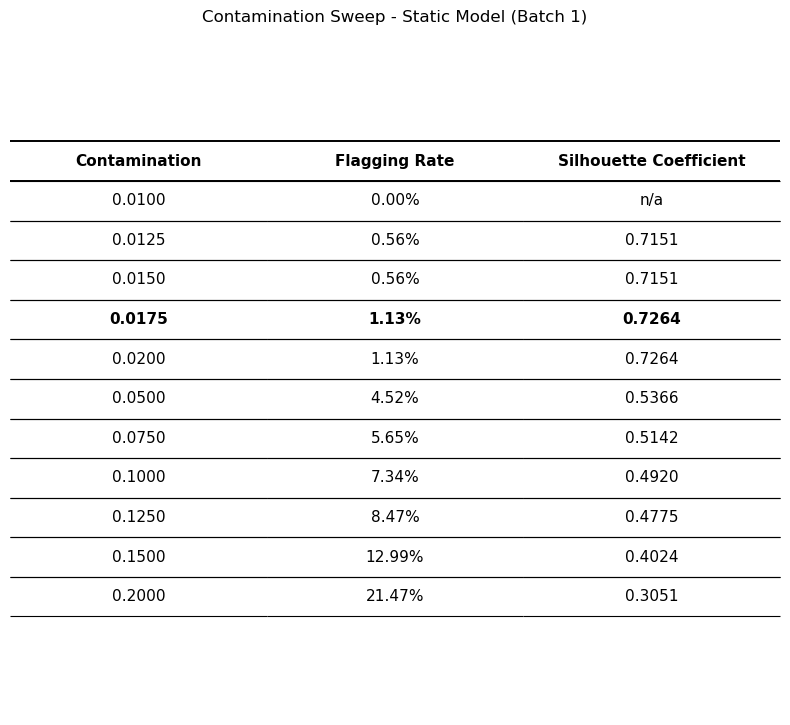

In [ ]:
import matplotlib.pyplot as plt

def render_contamination_table(contamination_results, selected_contamination, title, filename):
    """
    Renders the contamination sweep results as a table image, with the
    row matching `selected_contamination` bolded and highlighted -- so
    the winning value is visually obvious regardless of how many
    candidates were tested or what values they were.
    """
    df = contamination_results.copy()
    df["contamination"] = df["contamination"].map(lambda v: f"{v:.4f}")
    df["flagging_rate"] = df["flagging_rate"].map(lambda v: f"{v*100:.2f}%")
    df["silhouette"] = df["silhouette"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.4f}")
    df.columns = ["Contamination", "Flagging Rate", "Silhouette Coefficient"]

    highlight_row = contamination_results.index[
        contamination_results["contamination"] == selected_contamination
    ]
    highlight_row = highlight_row[0] if len(highlight_row) else None

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(df) + 1.3))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.0)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.visible_edges = "horizontal"
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.4)
        if highlight_row is not None and row == highlight_row + 1:
            cell.set_facecolor("#d5f5e3")
            cell.set_text_props(weight="bold")

    plt.title(title, fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

render_contamination_table(
    contamination_results, CONTAMINATION,
    title="Contamination Sweep - Static Model (Batch 1)"
)


In [12]:
raw_pred = model.predict(X_test)
flags = (raw_pred == -1).astype(int)
scores = model.decision_function(X_test)
anomaly_scores = -scores

flagging_rate = flags.mean()
print(f"Flagging Rate: {flagging_rate:.2%}")

print("\nAnomaly Score Distribution:")
print(f"  Mean : {anomaly_scores.mean():.4f}")
print(f"  Std  : {anomaly_scores.std():.4f}")
print(f"  Min  : {anomaly_scores.min():.4f}")
print(f"  Max  : {anomaly_scores.max():.4f}")

if len(set(flags)) > 1:
    sil_score = silhouette_score(X_test, flags)
    print(f"\nSilhouette Coefficient: {sil_score:.4f}")
else:
    sil_score = None
    print("\nSilhouette Coefficient: N/A (only one cluster flagged)")

autoencoder = MLPRegressor(
    hidden_layer_sizes=(max(2, X_train.shape[1] // 2),),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_SEED,
)
autoencoder.fit(X_train, X_train)
X_test_reconstructed = autoencoder.predict(X_test)
reconstruction_error = np.mean((X_test - X_test_reconstructed) ** 2, axis=1)
print(f"\nReconstruction Error (mean): {reconstruction_error.mean():.4f}")
print(f"Reconstruction Error (std) : {reconstruction_error.std():.4f}")

lof = LocalOutlierFactor(n_neighbors=min(20, len(X_test) - 1), novelty=False)
lof_pred = lof.fit_predict(X_test)
lof_flags = (lof_pred == -1).astype(int)
print(f"\nLOF flagged anomalies: {lof_flags.sum()} / {len(lof_flags)}")

both_flagged = ((flags == 1) & (lof_flags == 1)).sum()
only_if = ((flags == 1) & (lof_flags == 0)).sum()
only_lof = ((flags == 0) & (lof_flags == 1)).sum()
print(f"Flagged by both IF and LOF : {both_flagged}")
print(f"Flagged by IF only         : {only_if}")
print(f"Flagged by LOF only        : {only_lof}")

Flagging Rate: 1.13%

Anomaly Score Distribution:
  Mean : -0.1778
  Std  : 0.0626
  Min  : -0.2356
  Max  : 0.0961

Silhouette Coefficient: 0.7150

Reconstruction Error (mean): 0.1706
Reconstruction Error (std) : 0.9814

LOF flagged anomalies: 46 / 177
Flagged by both IF and LOF : 2
Flagged by IF only         : 0
Flagged by LOF only        : 44


c:\Users\Lazaro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lazaro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Lazaro\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lazaro\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Lazaro\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

In [14]:
test_profiles = ip_profiles.iloc[test_idx].reset_index(drop=True).copy()
test_profiles["anomaly_score"] = anomaly_scores
test_profiles["flagged"] = flags
top_flagged = test_profiles.sort_values("anomaly_score", ascending=False).head(10)
print("\nTop 10 highest-anomaly-score attacker IPs (for manual face-validity check):")
print(top_flagged[["source_ip", "total_packets", "unique_dst_ports",
                    "syn_ratio", "avg_conn_rate", "anomaly_score", "flagged"]])


Top 10 highest-anomaly-score attacker IPs (for manual face-validity check):
          source_ip  total_packets  unique_dst_ports  syn_ratio  \
155  222.71.127.234          682.0               1.0   0.004399   
20    79.124.56.106        30765.0               1.0   0.088867   
117   94.232.43.203        11305.0               1.0   0.092968   
111    195.3.147.52         1337.0               1.0   0.050112   
98      218.92.0.60           63.0               1.0   0.015873   
26     185.94.111.1            1.0               0.0   0.000000   
75     47.252.29.89          249.0               2.0   0.160643   
56    95.214.55.244           14.0               1.0   0.142857   
82   139.59.181.152            5.0               1.0   0.400000   
17      49.143.32.6            5.0               1.0   0.200000   

     avg_conn_rate  anomaly_score  flagged  
155     197.781525       0.096097        1  
20      841.194604       0.004385        1  
117     320.895798      -0.000135        0  
111  

In [15]:
anomaly_scores_test = test_profiles["anomaly_score"].values
threshold_70 = np.percentile(anomaly_scores_test, 70)

# Representative port per attacker IP = most frequently targeted dst_port
rep_ports = (
    inbound[inbound["source_ip"].isin(test_profiles["source_ip"])]
    .groupby("source_ip")["dst_port"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

rules = []
for score, (i, row) in zip(anomaly_scores_test, test_profiles.iterrows()):
    action = "ESCALATE_TO_ANALYST" if score >= threshold_70 else "ALLOW"
    rules.append({
        "source_ip": row["source_ip"],
        "port": rep_ports.get(row["source_ip"], np.nan),
        "anomaly_score": round(float(score), 4),
        "action": action,
    })

rules_df = pd.DataFrame(rules).sort_values("anomaly_score", ascending=False).reset_index(drop=True)
print("\nSample generated firewall rules:")
print(rules_df.head(10))
print(f"\nESCALATE_TO_ANALYST: {(rules_df.action == 'ESCALATE_TO_ANALYST').sum()}, "
      f"ALLOW: {(rules_df.action == 'ALLOW').sum()}")
print("(No records are auto-blocked. BLOCK is an analyst decision made after reviewing "
      "an ESCALATE_TO_ANALYST record, not an automated label.)")



Sample generated firewall rules:
        source_ip    port  anomaly_score               action
0  222.71.127.234  1433.0         0.0961  ESCALATE_TO_ANALYST
1   79.124.56.106  5900.0         0.0044  ESCALATE_TO_ANALYST
2   94.232.43.203  5900.0        -0.0001  ESCALATE_TO_ANALYST
3    195.3.147.52    22.0        -0.0074  ESCALATE_TO_ANALYST
4     218.92.0.60    22.0        -0.0084  ESCALATE_TO_ANALYST
5    185.94.111.1     NaN        -0.0325  ESCALATE_TO_ANALYST
6    47.252.29.89  5432.0        -0.0411  ESCALATE_TO_ANALYST
7   95.214.55.244    80.0        -0.0563  ESCALATE_TO_ANALYST
8  139.59.181.152  5060.0        -0.0589  ESCALATE_TO_ANALYST
9     49.143.32.6  5555.0        -0.0671  ESCALATE_TO_ANALYST

ESCALATE_TO_ANALYST: 53, ALLOW: 124
(No records are auto-blocked. BLOCK is an analyst decision made after reviewing an ESCALATE_TO_ANALYST record, not an automated label.)


Anomaly Score Distribution

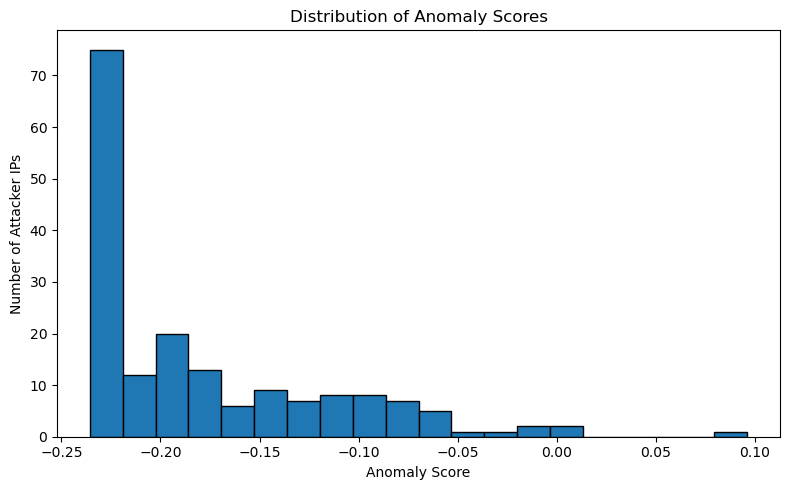

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(anomaly_scores, bins=20, edgecolor="black")

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Attacker IPs")
plt.title("Distribution of Anomaly Scores")

plt.tight_layout()
plt.show()

Normal vs Anomalous IPs

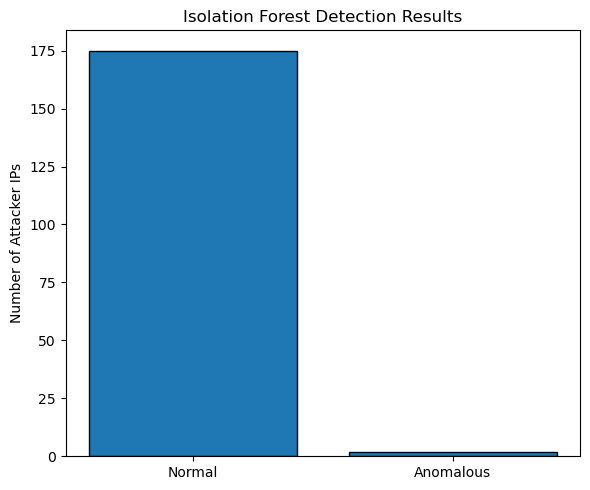

In [ ]:
normal_count = (flags == 0).sum()
anomaly_count = (flags == 1).sum()

plt.figure(figsize=(6, 5))

plt.bar(
    ["Normal", "Anomalous"],
    [normal_count, anomaly_count],
    edgecolor="black"
)

plt.ylabel("Number of Attacker IPs")
plt.title("Isolation Forest Detection Results")

plt.tight_layout()
plt.show()

Isolation Forestn vs LOF

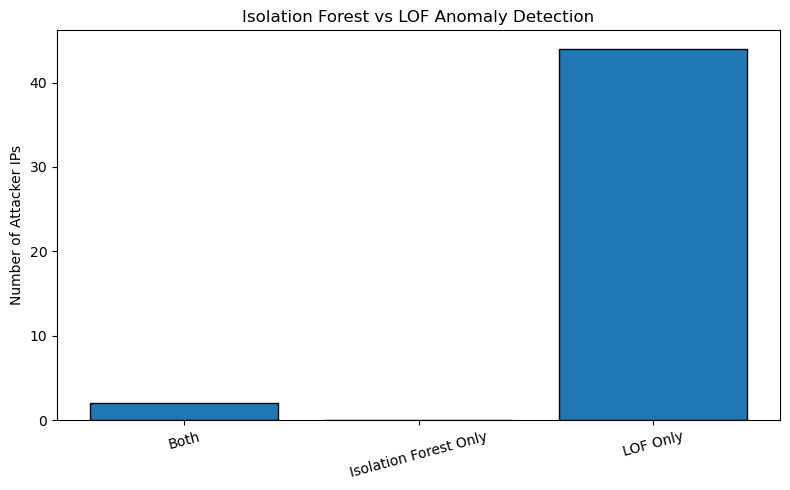

In [ ]:
both_flagged = ((flags == 1) & (lof_flags == 1)).sum()
if_only = ((flags == 1) & (lof_flags == 0)).sum()
lof_only = ((flags == 0) & (lof_flags == 1)).sum()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Both", "Isolation Forest Only", "LOF Only"],
    [both_flagged, if_only, lof_only],
    edgecolor="black"
)

plt.ylabel("Number of Attacker IPs")
plt.title("Isolation Forest vs LOF Anomaly Detection")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Top 10 Anomalous IPs

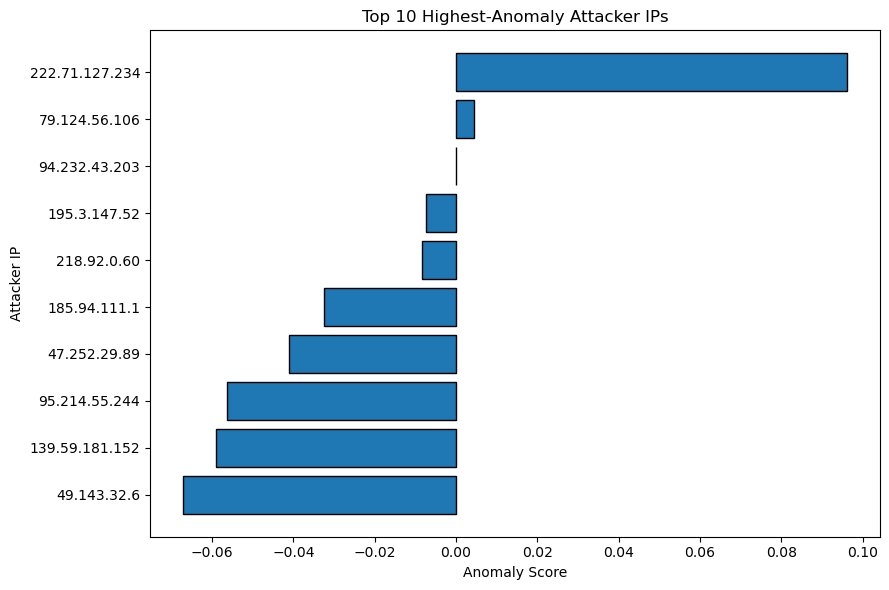

In [ ]:
top10 = top_flagged.sort_values("anomaly_score")

plt.figure(figsize=(9, 6))

plt.barh(
    top10["source_ip"].astype(str),
    top10["anomaly_score"],
    edgecolor="black"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Attacker IP")
plt.title("Top 10 Highest-Anomaly Attacker IPs")

plt.tight_layout()
plt.show()

Firewall Actions

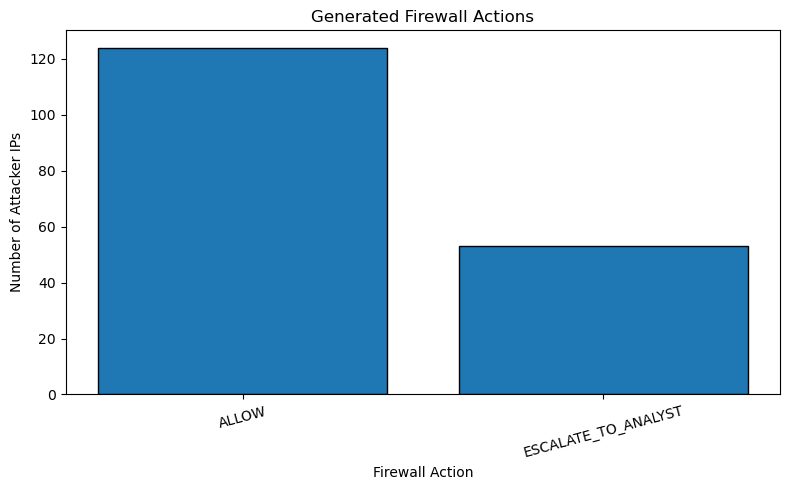

In [ ]:
action_counts = rules_df["action"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    action_counts.index,
    action_counts.values,
    edgecolor="black"
)

plt.xlabel("Firewall Action")
plt.ylabel("Number of Attacker IPs")
plt.title("Generated Firewall Actions")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Anomaly score vs Packet count

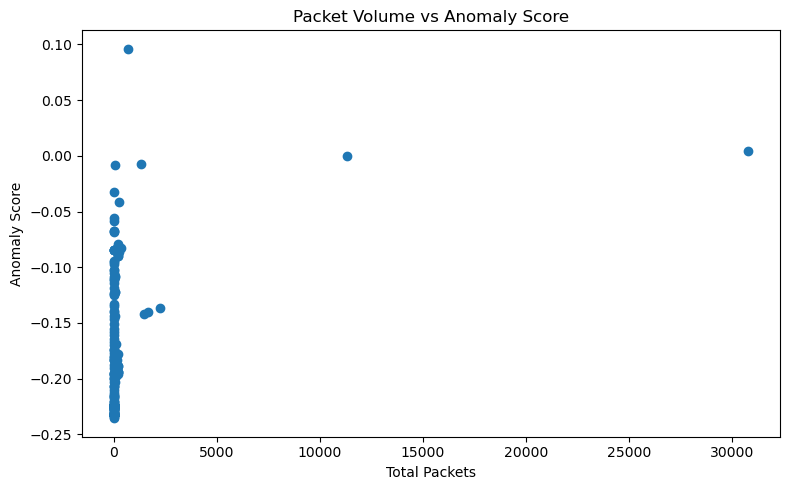

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    test_profiles["total_packets"],
    test_profiles["anomaly_score"]
)

plt.xlabel("Total Packets")
plt.ylabel("Anomaly Score")
plt.title("Packet Volume vs Anomaly Score")

plt.tight_layout()
plt.show()

Anomaly Score vs Connection Rate

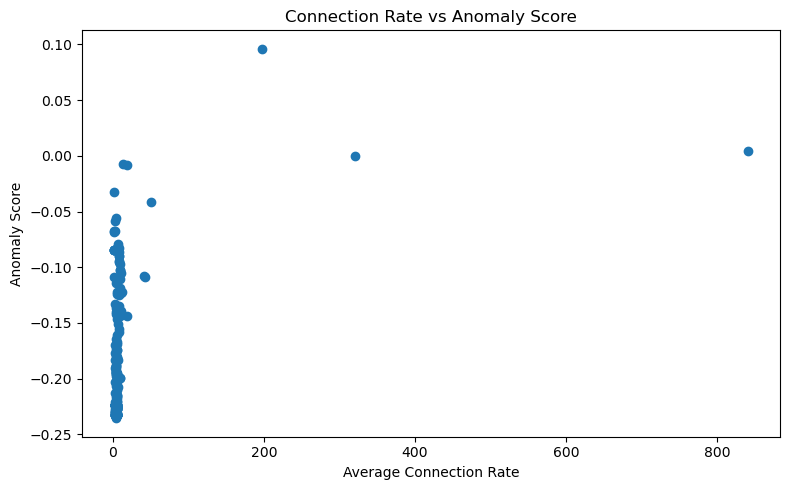

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    test_profiles["avg_conn_rate"],
    test_profiles["anomaly_score"]
)

plt.xlabel("Average Connection Rate")
plt.ylabel("Anomaly Score")
plt.title("Connection Rate vs Anomaly Score")

plt.tight_layout()
plt.show()